In [2]:
pip install google-cloud-bigquery pandas pyarrow matplotlib seaborn plotly

   ---------------------------------------- 0.0/5.0 MB ? eta -:--:--
   ---------------------------------------- 5.0/5.0 MB 27.9 MB/s  0:00:00
   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   ------- -------------------------------- 5.5/28.0 MB 25.9 MB/s eta 0:00:01
   --------------- ------------------------ 11.0/28.0 MB 25.7 MB/s eta 0:00:01
   ---------------------- ----------------- 16.0/28.0 MB 25.4 MB/s eta 0:00:01
   ------------------------------- -------- 21.8/28.0 MB 25.6 MB/s eta 0:00:01
   ---------------------------------------  27.5/28.0 MB 26.0 MB/s eta 0:00:01
   ---------------------------------------- 28.0/28.0 MB 24.7 MB/s  0:00:01

   ----------------------------------------  0/11 [pyarrow]
   ----------------------------------------  0/11 [pyarrow]
   ----------------------------------------  0/11 [pyarrow]
   ----------------------------------------  0/11 [pyarrow]
   ----------------------------------------  0/11 [pyarrow]
   -------------

In [6]:
pip install db-dtypes

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   -------------------- ------------------- 5.8/11.1 MB 35.0 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 34.9 MB/s  0:00:00

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
  Attempting uninstall: pandas
   ---------------------------------------- 0/3 [pytz]
    Found existing installation: pandas 3.0.3
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [pandas]
    Uninstalling pandas-3.0.3:
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
      Successfully uninstalled pandas-3.0.3
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   -

  You can safely remove it manually.


BigQueryからデータを取得中...


c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


         date  daily_users  page_views  rolling_avg_pv
0  2020-11-01         2365        9767             NaN
1  2020-11-02         3262       14964             NaN
2  2020-11-03         4648       18665             NaN
3  2020-11-04         3734       15799             NaN
4  2020-11-05         3272       16249             NaN


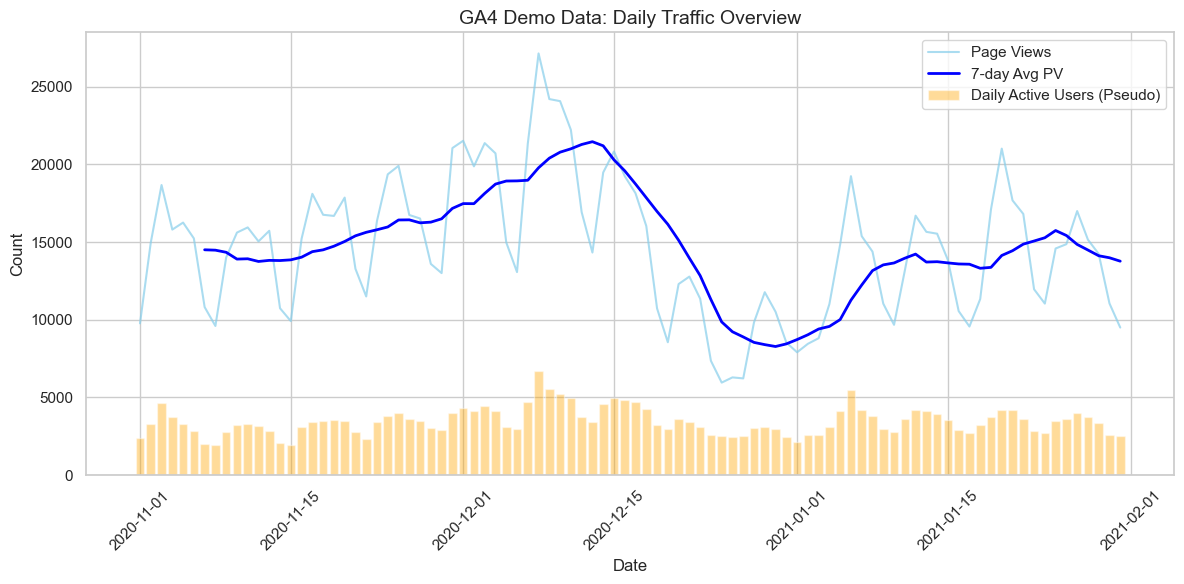

In [1]:
import os
import pandas as pd
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
# 1. dotenvのインポート
from dotenv import load_dotenv

# 2. .envファイルから環境変数を読み込む
load_dotenv()

# ※ load_dotenv() を実行するだけで、OSの環境変数に 
# GOOGLE_APPLICATION_CREDENTIALS が自動でセットされます。
# 念のため読み込めているか確認したい場合は以下を有効にしてください
# print("認証パス:", os.getenv("GOOGLE_APPLICATION_CREDENTIALS"))

# BigQueryクライアントの初期化（自動的に環境変数のパスが参照されます）
client = bigquery.Client()

# 3. SQLクエリの記述（以降は前回と同様です）
query = """
SELECT
    PARSE_DATE('%Y%m%d', event_date) AS date,
    COUNT(DISTINCT user_pseudo_id) AS daily_users,
    COUNTIF(event_name = 'page_view') AS page_views
FROM
    `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE
    _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
GROUP BY
    date
ORDER BY
    date ASC
"""

# 3. データの抽出とPandas DataFrameへの変換
print("BigQueryからデータを取得中...")
df = client.query(query).to_dataframe()

# 4. データ加工（例：移動平均の追加など）
df['rolling_avg_pv'] = df['page_views'].rolling(window=7).mean()
print(df.head())

# 5. 可視化（Matplotlib / Seabornを使用）
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# ユーザー数とPV数の推移をプロット
plt.plot(df['date'], df['page_views'], label='Page Views', color='skyblue', alpha=0.7)
plt.plot(df['date'], df['rolling_avg_pv'], label='7-day Avg PV', color='blue', linewidth=2)
plt.bar(df['date'], df['daily_users'], label='Daily Active Users (Pseudo)', color='orange', alpha=0.4)

plt.title('GA4 Demo Data: Daily Traffic Overview', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# グラフの表示
plt.show()

In [3]:
# 3. SQLクエリの記述
query = """
SELECT
  event_date,
  COUNT(DISTINCT user_pseudo_id) AS unique_users,
  COUNT(
    DISTINCT CONCAT(
      user_pseudo_id, 
      (SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id')
    )
  ) AS sessions,
  COUNTIF(event_name = 'page_view') AS page_views
FROM
  `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE
  _TABLE_SUFFIX BETWEEN '20210101' AND '20210131'
GROUP BY
  event_date
ORDER BY
  event_date ASC
"""  # ← この閉じ三連クォーテーションが抜けているか、ズレている可能性があります！

# データの抽出とPandas DataFrameへの変換
print("BigQueryからデータを取得中...")
df = client.query(query).to_dataframe()
print(df.head())

BigQueryからデータを取得中...


c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  event_date  unique_users  sessions  page_views
0   20210101          2160      2311        7906
1   20210102          2581      2734        8450
2   20210103          2579      2791        8812
3   20210104          3079      3373       11010
4   20210105          4101      4495       14850


In [5]:
import os
import pandas as pd
from google.cloud import bigquery
from dotenv import load_dotenv

# 環境変数の読み込みとクライアント初期化
load_dotenv()
client = bigquery.Client()

# クエリを代入（始まりの """ ）
query = """
SELECT
  event_name,
  ep.key AS parameter_key,
  COUNT(1) AS occurrence_count
FROM
  `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_20210131`,
  UNNEST(event_params) AS ep
GROUP BY
  event_name,
  parameter_key
ORDER BY
  event_name ASC,
  occurrence_count DESC
"""  # ← ここの閉じ三連クォーテーションが、途中で切れていた可能性が高いです！

# データの取得と表示
print("BigQueryからパラメータ一覧を取得中...")
df = client.query(query).to_dataframe()

# Jupyter Notebook上で綺麗に表示（先頭の30行を表示）
df.head(30)

BigQueryからパラメータ一覧を取得中...


c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_name,parameter_key,occurrence_count
0,add_payment_info,debug_mode,53
1,add_payment_info,page_title,53
2,add_payment_info,ga_session_number,53
3,add_payment_info,page_location,53
4,add_payment_info,page_referrer,53
5,add_payment_info,session_engaged,53
6,add_payment_info,ga_session_id,53
7,add_payment_info,currency,53
8,add_payment_info,engaged_session_event,50
9,add_payment_info,engagement_time_msec,31
